In [1]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import jax.numpy as jnp
import healpy as hp

import matplotlib.pyplot as plt

import megabuster

jax.config.update("jax_enable_x64", True)


# Generating input CMB and input mask

In [2]:
from fgbuster import get_observation, get_instrument

nside = 128 
npix = 12*nside**2
nstokes = 2


frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

# Get simulated map
instrument = get_instrument('SO_SAT')


np.random.seed(42)
input_freq_maps = get_observation(instrument, 'c1d0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)


0.1067962646484375

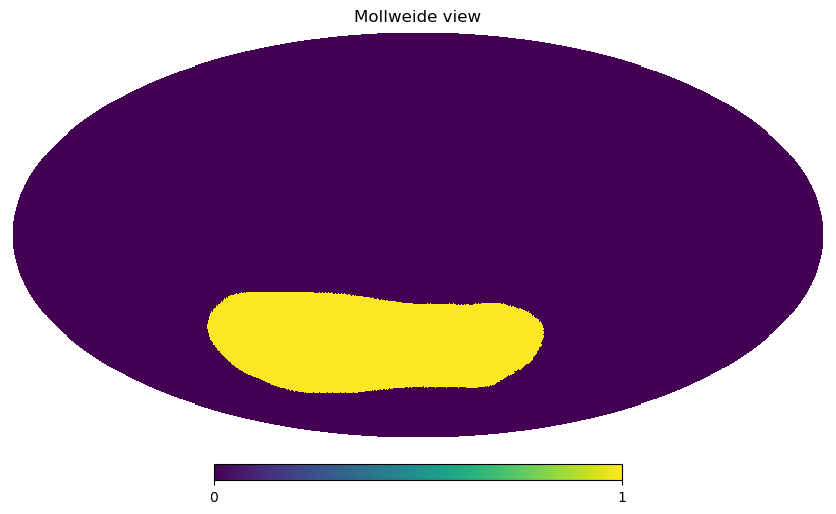

In [3]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

# path_MSS = '/lustre/fswork/projects/rech/nih/commun/megatop/MSS2/ivar/'
path_MSS = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/'
zero_threshold = 0.2
path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0

mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

# Preparing path and loading obsmat

In [4]:
# Preparing paths

# path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
# path_precomputations = path_scratch
# path_precomputations = '/lustre/fswork/projects/rech/nih/commun/megatop/precomputations/'

path_N = '/pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy'

# Prepare the paths of observation matrices 

# path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


# all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
# all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
# all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

# all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]


n_pix = mask_B_nest.sum()

In [5]:
indices_dust = megabuster.tools.get_healpix_indices_patch_from_mask(mask_B_ring, nside_patches=1)
indices_dust

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

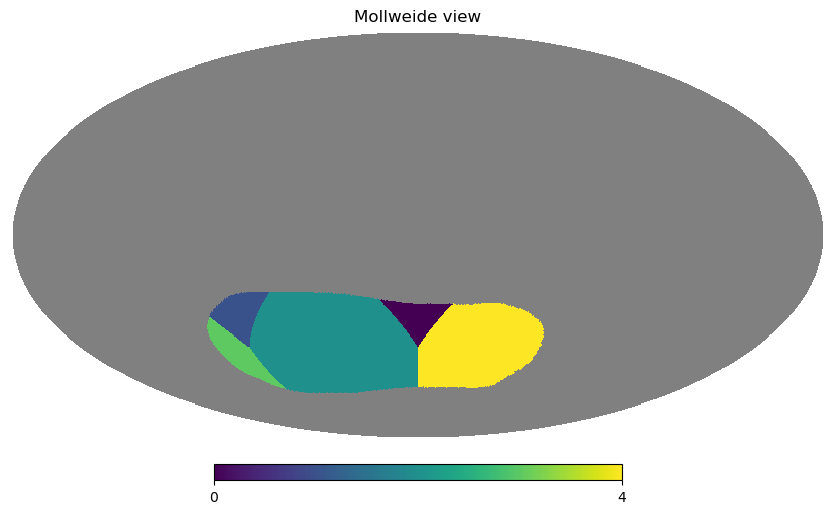

In [6]:
test_mollview = np.ones_like(mask_B_ring) * hp.UNSEEN
test_mollview[mask_B_ring != 0] = indices_dust

hp.mollview(test_mollview, )

In [7]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N)



Loading the inverse noise covariance matrix from /pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy


In [8]:
noisecov_QU_masked = N_matrix[:,1:,:] * mask_B_ring
inverse_noisecov_QU_masked = np.zeros_like(noisecov_QU_masked)
inverse_noisecov_QU_masked[noisecov_QU_masked != 0] = 1./noisecov_QU_masked[noisecov_QU_masked != 0]
inverse_noisecov_QU_masked.shape

(6, 2, 196608)

In [9]:
%%time
res_sanity = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        diag_obsmat_matrices=None,
        max_iter=20,
        tol=1e-6,
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
        patch_indices={'temp_dust_patches': None, 'beta_dust_patches': np.array(indices_dust, dtype=int), 'beta_pl_patches': None},
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!


Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
{'beta_dust': Array(1.54000011, dtype=float64), 'beta_pl': Array(-2.99999923, dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Converged in 2 iterations
CPU times: user 13.7 s, sys: 852 ms, total: 14.5 s
Wall time: 8.04 s


In [10]:
res_sanity.x

array([ 1.54000011, -2.99999923])

In [11]:
# {'beta_dust': jnp.array([1.54 for i in range(np.unique(indices_dust).size)]), 'beta_pl': jnp.array([-3.0])}
first_guess_params = {'beta_dust':  jnp.full((np.unique(indices_dust).size,) , 1.54), 'beta_pl': jnp.array([3.])}
first_guess_params

{'beta_dust': Array([1.54, 1.54, 1.54, 1.54, 1.54], dtype=float64, weak_type=True),
 'beta_pl': Array([3.], dtype=float64)}

In [14]:
%%time
res_sanity = megabuster.compsep.perform_compsep(
        first_guess_params=first_guess_params,
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        diag_obsmat_matrices=None,
        max_iter=20,
        tol=1e-6,
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
        patch_indices={'temp_dust_patches': None, 'beta_dust_patches': np.array(indices_dust, dtype=int), 'beta_pl_patches': None},
        optimize_func=megabuster.minimizers.new_filter_optimize,  # Use the filter_optimize function from megabuster. 
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!


TypeError: Custom JVP rule must produce primal and tangent outputs with corresponding shapes and dtypes. Expected float64[] (tangent type of float64[]) but got float64[5].

In [13]:
res_sanity.x

array([ 1.54000011, -2.99999923])